# Dataset generation

In [1]:
from dlroms import *
import os
import matplotlib as mpl
from dolfin import *
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output as clc
import gdown
from fenics import *

# Setup directories
savepath = os.path.join('..', 'data')
resultspath = os.path.join('..','results')
if not os.path.exists(savepath):
    os.makedirs(savepath)
if not os.path.exists(resultspath):
    os.makedirs(resultspath)

## Rod temperature (nonlinear diffusion)

**Partial differential equation**
</br></br>
$$\begin{cases}
-\nabla\cdot(\sigma(u)\nabla u) = f-\alpha u^{4} & \text{in}\;\Omega\\
-\sigma(u)\nabla u \cdot \boldsymbol{n} = 0 & \text{on}\;\partial\Omega\setminus\left(\cup_{i=1}^{3}\Gamma_{i}\right)\\
u = T_{i} & \text{on}\;\Gamma_{i}
\end{cases}$$
</br>
where:

- $\sigma(u):=10^3 + e^{u/8}$,

- $\Gamma_{1},\Gamma_{2},\Gamma_{3}$ are the inner left circle, inner right circle, and the "toothed region", respectively.</br></br>

**Model parameters**

| Parameter     | Range | Meaning  |
|----------|-----|-------------|
| $T_1$    | 80 to 120  | Contact temperature    |
| $T_2$    | 80 to 120  | Contact temperature    |
| $T_3$    | 80 to 120  | Contact temperature    |
| $\log_{10}f$ | 1.5 to 5 | External heat source |
| $\log_{10}\alpha$ |-3.5 to -1.5 | Thermal radiation coefficient|

#### Domain and FE space

In [2]:
gdown.download(
    id = "1-YmekOC5d1ACFsCAO0IEg5AuWji03SxF",
    output = os.path.join(savepath, "rod_mesh.xml"),
    quiet = True
)
mesh = fe.loadmesh(os.path.join(savepath, "rod_mesh.xml"))
Vh = fe.space(mesh, 'CG', 1)
clc()

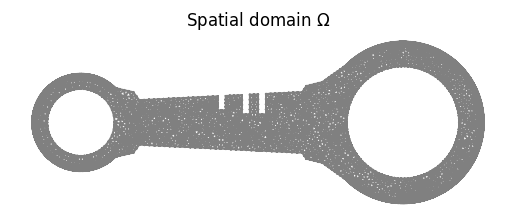

In [3]:
fe.plot(mesh)
plt.title("Spatial domain $\Omega$")
plt.show()

#### FOM

In [4]:
def FOMsolver(mu):

    # Portions of domain boundary subject to Dirichlet b.c.
    def leftCircle(x, on):
        return on and ((x[0]+2)**2 + x[1]**2)**0.5 < 0.5
    def rightCircle(x, on):
        return on and ((x[0]-2)**2 + x[1]**2)**0.5 < 0.8
    def rag(x, on):
        return on and (x[0]>-0.3) and (x[0]<0.3) and (x[1]>0)

    # Dirichlet BC application
    dbc1 = DirichletBC(Vh, Constant(mu[0]), leftCircle)
    dbc2 = DirichletBC(Vh, Constant(mu[1]), rightCircle)
    dbc3 = DirichletBC(Vh, Constant(mu[2]), rag)

    # Variational forms
    u, v = Function(Vh), TestFunction(Vh)
    L = inner((1000+exp(u/8.0))*grad(u), grad(v))*dx - \
        Constant(10**mu[3])*v*dx + (10**mu[4])*(u**4)*v*dx
    clc()

    # Solver
    u.vector()[:] = (mu[0]+mu[1]+mu[2])/3.0 # Initial guess for nonlinear solver
    solve(L == 0, u, [dbc1, dbc2, dbc3])
    
    return u.vector()[:]

In [5]:
param_range = np.array([[80, 120], [80, 120], [80, 120], [1.5, 5], [-3.5, -1.5]])

def FOMsampler(seed):
  np.random.seed(seed)
  mu = np.random.rand(5)*(param_range[:, 1]-param_range[:, 0]) + param_range[:, 0]
  u = FOMsolver(mu)
  return mu, u

#### Data generation

In [6]:
snapshots(n = 400, sampler = FOMsampler, filename = os.path.join(savepath, "rod_snapshots.npz"), verbose = True)

Snapshots generated. Elapsed time: 1 minutes 4.23 seconds.


#### Visualization

In [7]:
def visout(char, x):
  return (("["+(char+", ")*len(x)+"]") % tuple(x)).replace(", ]","]")

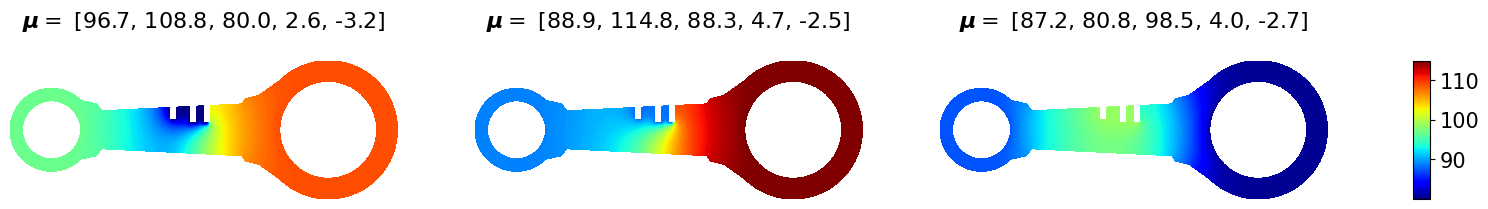

In [8]:
data = np.load(os.path.join(savepath, "rod_snapshots.npz"))
mu, u = data['mu'], data['u']

idxs_plot = (1,5,11)
shape = (1,3)
size = 17
fig = plt.figure(figsize = (shape[0]*size, shape[1]*size))
vmin = np.min(np.array([u[idx_sample] for idx_sample in idxs_plot]))
vmax = np.max(np.array([u[idx_sample] for idx_sample in idxs_plot]))
for idx_plot, idx_sample in enumerate(idxs_plot):
    plt.subplot(shape[0], shape[1], idx_plot+1)
    img = fe.plot(u[idx_sample], space = Vh, vmin = vmin, vmax = vmax)
    plt.title("$\\boldsymbol{\\mu}=$ %s\n" % (visout("%.1f", mu[idx_sample])), fontsize = 16)
    

my_scalar_mappable = mpl.cm.ScalarMappable(norm=None, cmap='jet')
my_scalar_mappable.set_array(np.linspace(vmin,vmax,1001))
last_ax = plt.subplot(shape[0], shape[1], 3)
l, b, w, h = last_ax.get_position().bounds
cax = last_ax.figure.add_axes(
    [l + w + 0.05, b, 0.01, h]
)
fig.colorbar(my_scalar_mappable, cax = cax)
cax.tick_params(axis='both', which='major', labelsize=15)
plt.savefig(os.path.join(resultspath, 'samples_rod.png'), bbox_inches='tight')

## Anti-hail shield (linear elasticity)

**Partial differential equation**
</br></br>
\begin{cases}
        -\nabla\cdot\left(\lambda\nabla\cdot\boldsymbol{u} + \nu\left(\nabla\boldsymbol{u}+\nabla\boldsymbol{u}^{\top}\right)\right) = \boldsymbol{f} & \text{in }\Omega\\
        \boldsymbol{u}\equiv\mathbf{0} & \text{on }\Gamma_{\text{bottom}}\\
        \boldsymbol{u}\equiv\boldsymbol{T} & \text{on }\Gamma_{\text{top}}\\
        \lambda(\nabla\cdot \boldsymbol{u})\cdot\boldsymbol{n}+\nu\left(\nabla\boldsymbol{u}+\nabla\boldsymbol{u}^{\top}\right)\cdot\boldsymbol{n}\equiv\mathbf{0} & \text{on }\partial\Omega\setminus (\Gamma_{\text{down}}\cup\Gamma_{\text{top}}).\\
    \end{cases}
</br>

where:
- $\Omega = (0,1)^2$

- $\Gamma_{\text{bottom}}$ and $\Gamma_{\text{top}}$ are the bottom and top edge, respectively

- $\boldsymbol{T}(x,y)=\boldsymbol{1}_{[x_0-\delta,\;x_0+\delta]}(x)\cdot[\cos\theta,-\sin\theta]^\top m$

- $\boldsymbol{f}=[0, -\rho]^\top$


**Model parameters**

| Parameter     | Min | Max | Meaning  |
|----------|---|---|-------------|
| $\rho$    | 0.5 | 2  | Body force (shield)    |
| $\lambda$ |0.9 | 1.1 | First Lamé parameter (shield)|
| $\nu$ |0.5 | 1 | Second Lamé parameter (shield)|
| $m$    | 1 | 1.5  | Hail grain mass    |
| $\delta$    | 0.05 | 0.1  | Hail grain diameter    |
| $x_0$ | 0.3 | 0.7 | Impact location |
| $\theta$ |$\frac{\pi}{4}$ | $\frac{3\pi}{4}$ | Angle of impact|

In [9]:
mesh = fe.unitsquaremesh(20, 20)
Vh = fe.space(mesh, 'CG', 1, vector_valued = True)
clc()

#### Domain and FE space

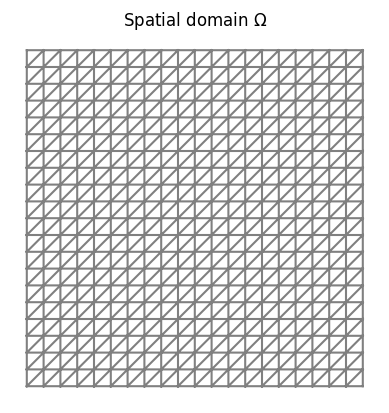

In [10]:
fe.plot(mesh)
plt.title("Spatial domain $\Omega$")
plt.show()
fe.savemesh(path = os.path.join(savepath, 'shield_mesh.xml'), mesh = mesh)

#### FOM

In [11]:
def FOMsolver(mu):
  rho, lambda_, nu, mass, delta, x0, theta = mu

  from ufl import nabla_div
  from scipy.sparse.linalg import spsolve
  from scipy.sparse import csr_matrix

  # Boundary conditions
  tol = 1e-14
  def clamped_boundary(x, on_boundary):
      return on_boundary and x[1]<tol
  bc = DirichletBC(Vh, Constant((0, 0)), clamped_boundary)

  # Auxiliary definitions
  def epsilon(u):
      return 0.5*(nabla_grad(u) + nabla_grad(u).T)

  def sigma(u):
      return lambda_*nabla_div(u)*Identity(2) + 2*nu*epsilon(u)

  # Variational problem
  u = TrialFunction(Vh)
  v = TestFunction(Vh)
  f = Constant((0, -rho))
  T = fe.interpolate(lambda x: [mass*np.cos(theta)*(x[1] > 0.99)*(np.abs(x[0]-x0)<delta),
                                   -mass*np.sin(theta)*(x[1] > 0.99)*(np.abs(x[0]-x0)<delta)], Vh)

  a = inner(sigma(u), epsilon(v))*dx
  L = dot(f, v)*dx + dot(T, v)*ds

  # Assembling and adjusting
  A = assemble(a)
  F = assemble(L)
  bc.apply(A)
  bc.apply(F)

  A = csr_matrix(A.array())
  F = F[:]

  # Solving
  u = spsolve(A, F)
  clc()
  return u

In [12]:
param_range = np.array([[0.5, 2], [0.9, 1.1], [0.5, 1], [1, 1.5], [0.05, 0.1], [0.3, 0.7], [np.pi/4.0, 3*np.pi/4.0]])

def FOMsampler(seed):
  p = len(param_range)
  np.random.seed(seed)
  mu = np.random.rand(p)*(param_range[:, 1]-param_range[:, 0]) + param_range[:, 0]
  u = FOMsolver(mu)
  return mu, u

#### Data generation

In [13]:
snapshots(n = 400, sampler = FOMsampler, filename = os.path.join(savepath, "shield_snapshots.npz"), verbose = True)

Snapshots generated. Elapsed time: 5.33 seconds.


#### Visualization

In [14]:
def visout(char, x):
  line1 = (("["+(char+", ")*(len(x)-4)+"\n") % tuple(x[:-4])).replace(", ]","]")
  line2 = (("                    "+(char+", ")*(4)+"]") % tuple(x[-4:])).replace(", ]","]")
  return line1 + line2

In [15]:
V1 = fe.space(mesh, "CG", 1)
def deformed_mesh(u):
  permutation = vertex_to_dof_map(V1)
  deformed = fe.unitsquaremesh(20, 20)
  x_delta = u[::2]+0.0
  y_delta = u[1::2]+0.0
  deformed.coordinates()[:, 0] = deformed.coordinates()[:, 0] + x_delta[permutation]
  deformed.coordinates()[:, 1] = deformed.coordinates()[:, 1] + y_delta[permutation]
  return deformed

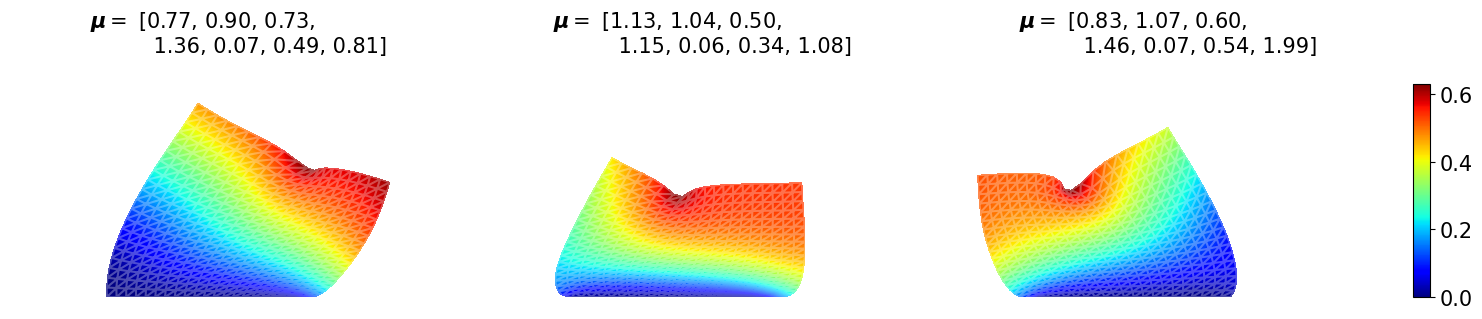

In [16]:
import numpy as np
from dolfin import plot as dolfin_plot
data = np.load(os.path.join(savepath, "shield_snapshots.npz"))
mu, u = data['mu'], data['u']

idxs_plot = (11,1,5)
shape = (1,3)
size = 17
comp_magn = lambda u: np.sqrt(u[::2]**2 + u[1::2]**2)
vmin = np.min(np.array([comp_magn(u[idx_sample]) for idx_sample in idxs_plot]))
vmax = np.max(np.array([comp_magn(u[idx_sample]) for idx_sample in idxs_plot]))
fig = plt.figure(figsize = (shape[0]*size, shape[1]*size))
for idx_plot, idx_sample in enumerate(idxs_plot):
    curr_deformed_mesh = deformed_mesh(u[idx_sample])
    V_def = fe.space(curr_deformed_mesh, "CG", 1)
    to_plot = comp_magn(u[idx_sample])
    plt.subplot(shape[0], shape[1], idx_plot+1)
    for idx_sample2 in idxs_plot:
        dolfin_plot(deformed_mesh(u[idx_sample2]), alpha = 0.0)
    fe.plot(to_plot, space = V_def)
    dolfin_plot(curr_deformed_mesh, color = 'white', alpha = 0.3)
    plt.title("$\\boldsymbol{\\mu}=$ %s\n" % (visout("%.2f", mu[idx_sample])), fontsize = 15)
    plt.xlim([-0.5,1.5])
    plt.ylim([-0,1.1])
my_scalar_mappable = mpl.cm.ScalarMappable(norm=None, cmap='jet')
my_scalar_mappable.set_array(np.linspace(vmin,vmax,1001))
last_ax = plt.subplot(shape[0], shape[1], 3)
l, b, w, h = last_ax.get_position().bounds
cax = last_ax.figure.add_axes(
    [l + w + 0.05, b, 0.01, h]
)
cbar = fig.colorbar(my_scalar_mappable, cax = cax)
cax.tick_params(axis='both', which='major', labelsize=15)
plt.savefig(os.path.join(resultspath, 'samples_shield.png'), bbox_inches='tight')

## Parameterized Gaussian

\begin{equation*}
u(x;\mu) = \exp(-400(x-\mu)^2), \qquad x \in [0,1], \quad  \mu \in [0.3,0.7]
\end{equation*}

In [17]:
mesh = UnitIntervalMesh(513)
fe.savemesh(path = os.path.join(savepath, 'gaussian_mesh.xml'), mesh = mesh)

In [18]:
def FOMsampler(seed):
    x_mesh = mesh.coordinates()[:,0]
    np.random.seed(seed)
    mu = 0.3 + 0.4 * np.random.rand()
    sigma = 5e-2#1e-2 + 9e-2 * np.random.rand()
    return (mu, sigma), np.exp(- (sigma)**(-2) * (x_mesh - mu)**2)

In [19]:
snapshots(n = 400, sampler = FOMsampler, filename = os.path.join(savepath, "gaussian_snapshots.npz"), verbose = True)

Snapshots generated. Elapsed time: 0.24 seconds.


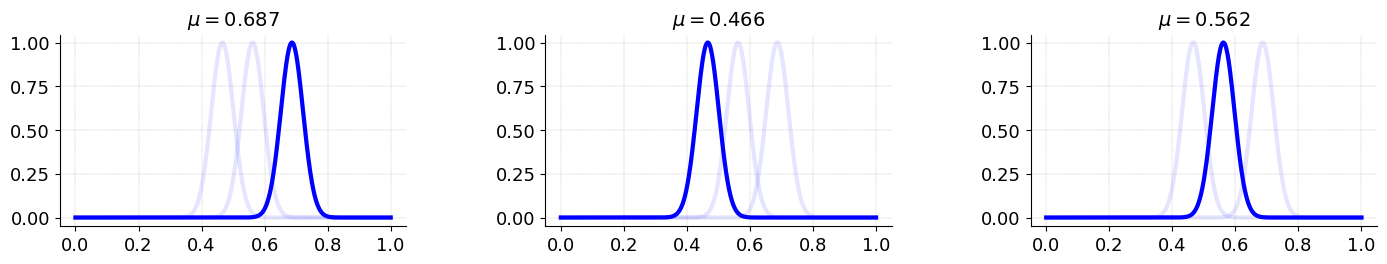

In [20]:
data = np.load(os.path.join(savepath, "gaussian_snapshots.npz"))
mu, u = data['mu'], data['u']
idxs_plot = (4, 368, 199)
fig, axs = plt.subplots(1, 3, figsize = (17, 2.5))
for idx_plot, ax in zip(idxs_plot, axs):
    curr_mu = mu[idx_plot,0]
    curr_sigma = mu[idx_plot,1]
    curr_u = u[idx_plot]
    ax.grid(color='grey', linestyle=':', linewidth=0.3)
    ax.plot(mesh.coordinates(), curr_u, 'b', linewidth = 3)
    ax.plot(mesh.coordinates(), u[idxs_plot,:].T, 'b', linewidth = 3, alpha = 0.10)
    for spine_name in('right', 'top'):
        ax.spines[spine_name].set_color('white')
    ax.set_title('$\\mu = %1.3f$' % curr_mu, fontsize = 14)
    #fig.axes.get_yaxis().set_visible(False)
    plt.subplots_adjust(wspace = 0.4)
    ax.tick_params(axis='both', which='major', labelsize=13)
plt.savefig(os.path.join(resultspath, 'samples_gaussian.png'), bbox_inches='tight')